In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

clinical_data = pd.read_csv(r"D:\GUVI\Projects\Clinical Trial Disease_project5\clinical_trials_raw_patient2trial_conditions.csv")

In [3]:
clinical_data.shape

(60337, 16)

In [4]:
clinical_data.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='str')

In [5]:
clinical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [6]:
clinical_data.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [8]:
type(clinical_data)

pandas.DataFrame

In [9]:
clinical_nlp = clinical_data[['brief_summary', 'source_condition_query']].copy()

clinical_nlp.head()

,brief_summary,source_condition_query
0,Breast cancer patients often have perioperativ...,breast cancer
1,Many breast cancer patients experience psychol...,breast cancer
2,"Based on an American study by Scherer et al., ...",breast cancer
3,Compare the effect of ropivacaine versus place...,breast cancer
4,Phase 1 dose escalation and expansion study of...,breast cancer


In [10]:
clinical_nlp.columns = ['summary', 'disease_category']

clinical_nlp.head()

,summary,disease_category
0,Breast cancer patients often have perioperativ...,breast cancer
1,Many breast cancer patients experience psychol...,breast cancer
2,"Based on an American study by Scherer et al., ...",breast cancer
3,Compare the effect of ropivacaine versus place...,breast cancer
4,Phase 1 dose escalation and expansion study of...,breast cancer


In [11]:
clinical_nlp.isnull().sum()

summary             0
disease_category    0
dtype: int64

In [12]:
clinical_nlp.duplicated().sum()

np.int64(265)

In [13]:
print("Before:", clinical_nlp.shape)

clinical_nlp = clinical_nlp.drop_duplicates()

print("After:", clinical_nlp.shape)

Before: (60337, 2)
After: (60072, 2)


In [14]:
disease_counts = clinical_nlp['disease_category'].value_counts()

disease_counts

disease_category
breast cancer                            16265
type 2 diabetes                          11398
covid-19                                 10103
anxiety                                   9260
chronic obstructive pulmonary disease     6142
rheumatoid arthritis                      3618
glaucoma                                  2150
sickle cell anemia                        1136
Name: count, dtype: int64

In [15]:
round(
clinical_nlp['disease_category'].value_counts(normalize=True)*100,
2)

disease_category
breast cancer                            27.08
type 2 diabetes                          18.97
covid-19                                 16.82
anxiety                                  15.41
chronic obstructive pulmonary disease    10.22
rheumatoid arthritis                      6.02
glaucoma                                  3.58
sickle cell anemia                        1.89
Name: proportion, dtype: float64

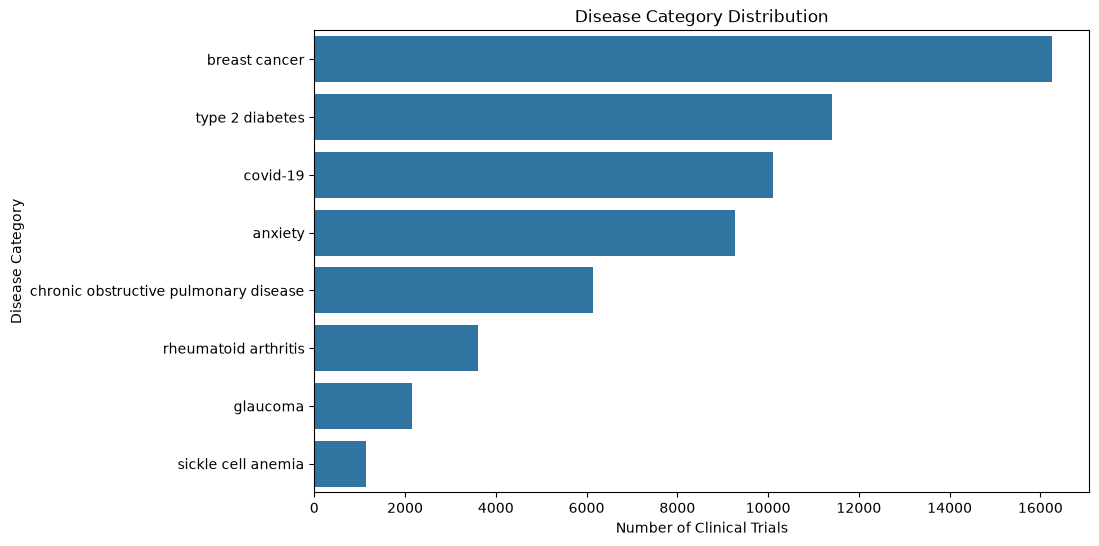

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='disease_category',
    data=clinical_nlp,
    order=clinical_nlp['disease_category'].value_counts().index
)

plt.title("Disease Category Distribution")
plt.xlabel("Number of Clinical Trials")
plt.ylabel("Disease Category")

plt.show()

In [17]:
clinical_nlp['summary_length'] = clinical_nlp['summary'].str.len()

clinical_nlp['summary_length'].describe()

count    60072.000000
mean       689.583300
std        631.121976
min         17.000000
25%        253.000000
50%        467.000000
75%        906.000000
max       5011.000000
Name: summary_length, dtype: float64

In [18]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [19]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [20]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [21]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [22]:
clinical_nlp['clean_summary'] = clinical_nlp['summary'].apply(clean_text)

In [23]:
clinical_nlp

,summary,disease_category,summary_length,clean_summary
0,Breast cancer patients often have perioperativ...,breast cancer,499,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,breast cancer,2113,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",breast cancer,338,based american study scherer et al hypothesize...
3,Compare the effect of ropivacaine versus place...,breast cancer,172,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,breast cancer,176,phase 1 dose escalation expansion study clsp 1...
...,...,...,...,...
60332,Zinc is a nutritionally essential trace elemen...,sickle cell anemia,778,zinc nutritionally essential trace element fou...
60333,"Multi-phase, patient navigator-based program i...",sickle cell anemia,501,multi phase patient navigator based program ri...
60334,Sickle cell disease (SCD) is the most common i...,sickle cell anemia,1490,sickle cell disease scd common inherited disor...
60335,A promising approach for the treatment of gene...,sickle cell anemia,1625,promising approach treatment genetic disease c...


In [24]:
clinical_nlp['clean_summary_len']= clinical_nlp['clean_summary'].str.len()

In [25]:
clinical_nlp

,summary,disease_category,summary_length,clean_summary,clean_summary_len
0,Breast cancer patients often have perioperativ...,breast cancer,499,breast cancer patient often perioperative emot...,386
1,Many breast cancer patients experience psychol...,breast cancer,2113,many breast cancer patient experience psycholo...,1635
2,"Based on an American study by Scherer et al., ...",breast cancer,338,based american study scherer et al hypothesize...,239
3,Compare the effect of ropivacaine versus place...,breast cancer,172,compare effect ropivacaine versus placebo pect...,146
4,Phase 1 dose escalation and expansion study of...,breast cancer,176,phase 1 dose escalation expansion study clsp 1...,145
...,...,...,...,...,...
60332,Zinc is a nutritionally essential trace elemen...,sickle cell anemia,778,zinc nutritionally essential trace element fou...,605
60333,"Multi-phase, patient navigator-based program i...",sickle cell anemia,501,multi phase patient navigator based program ri...,392
60334,Sickle cell disease (SCD) is the most common i...,sickle cell anemia,1490,sickle cell disease scd common inherited disor...,1106
60335,A promising approach for the treatment of gene...,sickle cell anemia,1625,promising approach treatment genetic disease c...,1190


In [26]:
X = clinical_nlp['clean_summary']
y = clinical_nlp['disease_category']

In [27]:
X

0        breast cancer patient often perioperative emot...
1        many breast cancer patient experience psycholo...
2        based american study scherer et al hypothesize...
3        compare effect ropivacaine versus placebo pect...
4        phase 1 dose escalation expansion study clsp 1...
                               ...                        
60332    zinc nutritionally essential trace element fou...
60333    multi phase patient navigator based program ri...
60334    sickle cell disease scd common inherited disor...
60335    promising approach treatment genetic disease c...
60336    sickle cell disease scd refers group hemoglobi...
Name: clean_summary, Length: 60072, dtype: str

In [28]:
y

0             breast cancer
1             breast cancer
2             breast cancer
3             breast cancer
4             breast cancer
                ...        
60332    sickle cell anemia
60333    sickle cell anemia
60334    sickle cell anemia
60335    sickle cell anemia
60336    sickle cell anemia
Name: disease_category, Length: 60072, dtype: str

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)


In [30]:
X_tfidf = tfidf.fit_transform(X)

In [31]:
X_tfidf.shape

(60072, 5000)

In [32]:
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2609873 stored elements and shape (60072, 5000)>
  Coords	Values
  (0, 706)	0.14359236987612897
  (0, 754)	0.13918399121976346
  (0, 3364)	0.1363737570186605
  (0, 3206)	0.12753805926201264
  (0, 3405)	0.17956092655872857
  (0, 1576)	0.14152918162694592
  (0, 1404)	0.10976011103545365
  (0, 427)	0.17624105350595126
  (0, 1296)	0.2279635546461652
  (0, 2632)	0.12107504422802802
  (0, 3496)	0.14681102522849532
  (0, 3737)	0.2812715615465726
  (0, 3835)	0.2888347682463591
  (0, 4420)	0.03662586174998038
  (0, 311)	0.07154043498412482
  (0, 1326)	0.08737146659723112
  (0, 4946)	0.09124513274581703
  (0, 2570)	0.42344352508736544
  (0, 1139)	0.23343811137140688
  (0, 2312)	0.2899712511054322
  (0, 4206)	0.1363598786334725
  (0, 3518)	0.14535065337881628
  (0, 3307)	0.10697365922001519
  (0, 1829)	0.13960203813091762
  (0, 4724)	0.07193486123903642
  :	:
  (60071, 3072)	0.06287857586783761
  (60071, 4180)	0.07129840067150806
  (60

In [33]:
tfidf.get_feature_names_out()

array(['00', '000', '001', ..., 'zinc', 'zoledronic', 'zoom'],
      shape=(5000,), dtype=object)

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
                                X_tfidf,
                                y,
                                test_size=.2,
                                random_state=42,
                                stratify=y)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(48057, 5000)
(12015, 5000)
(48057,)
(12015,)


In [36]:
from sklearn.linear_model import LogisticRegression

logic_regression = LogisticRegression()

In [37]:
logic_regression.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [38]:
y_pred = logic_regression.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9447357469829379
                                       precision    recall  f1-score   support

                              anxiety       0.89      0.96      0.92      1852
                        breast cancer       0.96      0.97      0.96      3253
chronic obstructive pulmonary disease       0.94      0.88      0.91      1228
                             covid-19       0.97      0.94      0.95      2021
                             glaucoma       0.97      0.91      0.94       430
                 rheumatoid arthritis       0.95      0.89      0.92       724
                   sickle cell anemia       0.97      0.85      0.91       227
                      type 2 diabetes       0.95      0.97      0.96      2280

                             accuracy                           0.94     12015
                            macro avg       0.95      0.92      0.94     12015
                         weighted avg       0.95      0.94      0.94     12015



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1771   30   18   14    2    6    0   11]
 [  48 3168    7    8    0    3    3   16]
 [  50   34 1082   17    3    6    1   35]
 [  60   22   15 1895    0    4    1   24]
 [   8   13    4    2  391    6    0    6]
 [  16   17    5    8    3  647    0   28]
 [   9    8    7    2    0    0  194    7]
 [  32   22    8    5    3    7    0 2203]]


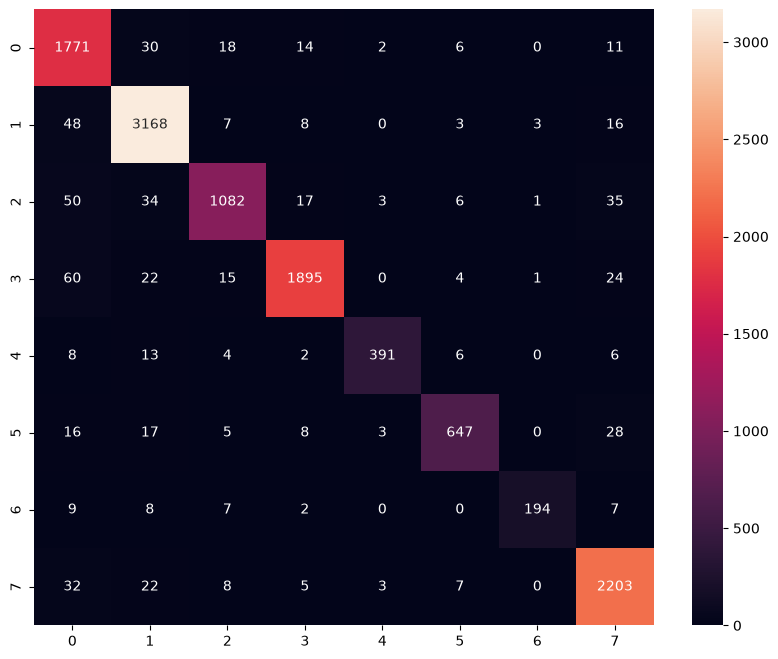

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [42]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

In [43]:
nb_model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](8,)","[ 7408.,13012., 4914.,..., 2894., 909., 9118.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](8,)","[-1.87,-1.31,-2.28,...,-2.81,-3.97,-1.66]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U37](8,)","['anxiety','breast cancer','chronic obstructive pulmonary disease',..., 'rheumatoid arthritis','sickle cell anemia','type 2 diabetes']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](8, 5000)","[[ 1.91, 4.38, 0.59,..., 1.06, 0. , 3.05], [ 0.8 ,10.28, 7.44,..., 0.59,12.92, 1.38], [ 0.38, 5.27, 1.87,..., 0.58, 0. , 0. ], ..., [ 0.11, 1.42, 2.09,..., 0.06, 0.23, 0. ], [ 0. , 3.12, 0.52,..., 2.16, 0.6 , 0. ], [ 2.26, 6.87, 3.47,..., 2.08, 0. , 0.55]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](8, 5000)","[[ -9.68, -9.06,-10.28,...,-10.02,-10.75, -9.35], [-10.61, -8.78, -9.07,...,-10.74, -8.57,-10.33], [-10.03, -8.51, -9.29,..., -9.89,-10.35,-10.35], ..., [ -9.76, -8.98, -8.73,..., -9.81, -9.65, -9.86], [ -9.21, -7.79, -8.79,..., -8.06, -8.74, -9.21], [ -9.68, -8.8 , -9.37,..., -9.74,-10.86,-10.43]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [44]:
y_pred_nb = nb_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

print("Accuracy:",accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))

Accuracy: 0.8966292134831461
                                       precision    recall  f1-score   support

                              anxiety       0.76      0.94      0.84      1852
                        breast cancer       0.95      0.92      0.93      3253
chronic obstructive pulmonary disease       0.94      0.80      0.87      1228
                             covid-19       0.92      0.89      0.90      2021
                             glaucoma       0.96      0.85      0.90       430
                 rheumatoid arthritis       0.96      0.80      0.88       724
                   sickle cell anemia       0.98      0.66      0.79       227
                      type 2 diabetes       0.90      0.95      0.92      2280

                             accuracy                           0.90     12015
                            macro avg       0.92      0.85      0.88     12015
                         weighted avg       0.90      0.90      0.90     12015



SVM

In [47]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [48]:
y_pred_svm = svm_model.predict(X_test)

In [54]:
print("Accuracy: ",accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))

Accuracy:  0.9470661672908864
                                       precision    recall  f1-score   support

                              anxiety       0.90      0.95      0.92      1852
                        breast cancer       0.96      0.97      0.97      3253
chronic obstructive pulmonary disease       0.93      0.89      0.91      1228
                             covid-19       0.97      0.94      0.96      2021
                             glaucoma       0.96      0.94      0.95       430
                 rheumatoid arthritis       0.93      0.91      0.92       724
                   sickle cell anemia       0.96      0.89      0.92       227
                      type 2 diabetes       0.95      0.96      0.96      2280

                             accuracy                           0.95     12015
                            macro avg       0.95      0.93      0.94     12015
                         weighted avg       0.95      0.95      0.95     12015



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1771   30   18   14    2    6    0   11]
 [  48 3168    7    8    0    3    3   16]
 [  50   34 1082   17    3    6    1   35]
 [  60   22   15 1895    0    4    1   24]
 [   8   13    4    2  391    6    0    6]
 [  16   17    5    8    3  647    0   28]
 [   9    8    7    2    0    0  194    7]
 [  32   22    8    5    3    7    0 2203]]


In [56]:
from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_test, y_pred_svm)

print(svm_cm)

[[1757   30   24   20    3    6    1   11]
 [  40 3168    8    7    2    6    2   20]
 [  51   27 1094   11    3   13    2   27]
 [  51   20   22 1903    1    4    1   19]
 [   4    4    2    2  406    8    0    4]
 [  10   12    7    4    2  660    1   28]
 [   6    3    9    1    1    2  201    4]
 [  30   20   16    8    5   10    1 2190]]


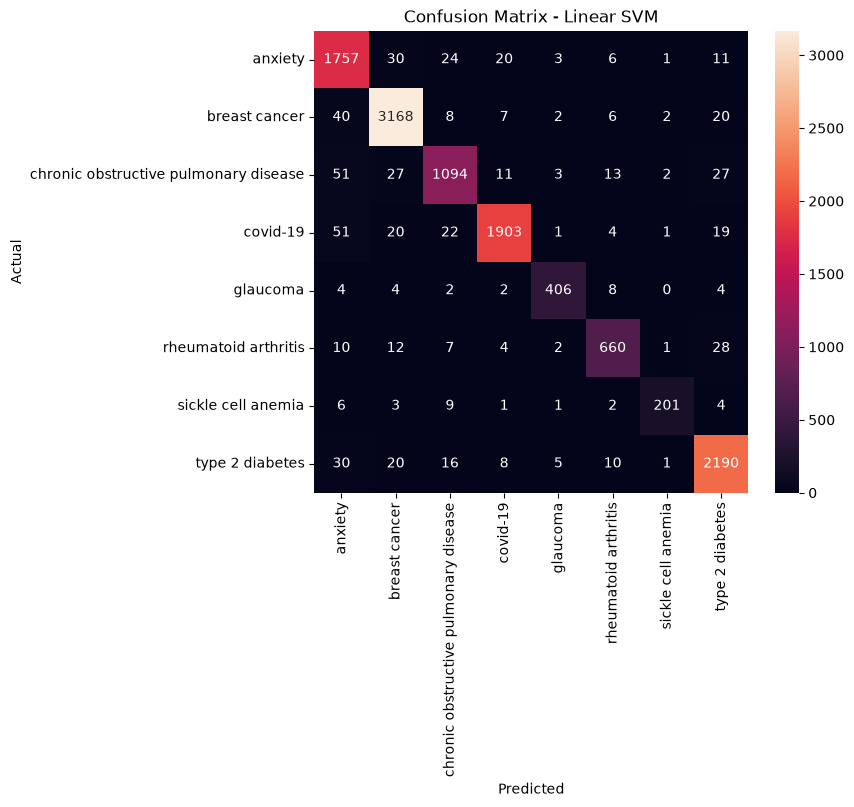

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [69]:
import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svm_model, "disease_classifier_svm.pkl")

['disease_classifier_svm.pkl']

In [71]:
load_tfidf = joblib.load('tfidf_vectorizer.pkl')
load_svm = joblib.load('disease_classifier_svm.pkl')


In [72]:
def predict_disease(summary):
    cleaned = clean_text(summary)
    vectorized = load_tfidf.transform([cleaned])
    prediction = load_svm.predict(vectorized)
    return prediction[0]

In [73]:
sample = """
This clinical trial studies insulin treatment and blood glucose control
in patients with type 2 diabetes.
"""

print(predict_disease(sample))

type 2 diabetes


In [74]:
import os

print(os.getcwd())

d:\GUVI\Projects\Clinical Trial Disease_project5


In [75]:
import os

print(os.listdir())

['app.py', 'clinical_nlp.ipynb', 'clinical_trials_raw_patient2trial_conditions.csv', 'clinical_venv', 'disease_classifier_svm.pkl', 'tfidf_vectorizer.pkl']
